In [3]:
import pandas as pd # type: ignore
import numpy as np
import matplotlib as plt  # type: ignore
import seaborn as sns # type: ignore
from sklearn.model_selection import train_test_split, GridSearchCV # type: ignore
from sklearn.metrics import mean_squared_error, r2_score # type: ignore
import os
import joblib # type: ignore
from sklearn.linear_model import Lasso

In [4]:
dr = pd.read_excel('smiles_without_phosphorus_in_ring.xlsx')
del dr['ID']
dr.head()


,smiles,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [7]:
df = pd.read_csv("Morgan.csv")
del df['ID']
df.head()

,smiles,morgan_fingerprint
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [17]:
morgan_file_path = 'Morgan.csv'
morgan_df = pd.read_csv(morgan_file_path)

df_without_phosphorus_in_ring = pd.read_excel('smiles_without_phosphorus_in_ring.xlsx')

if 'smiles' not in morgan_df.columns:
    raise ValueError("The column 'SMILES' was not found in the Morgan CSV file")

# Filter out rows from Morgan file where SMILES are in df_without_phosphorus_in_ring
filtered_morgan_df = morgan_df[morgan_df['smiles'].isin(df_without_phosphorus_in_ring['smiles'])]

# Save the filtered result to a new CSV file
output_filtered_morgan = 'filtered_Morgan.csv'
filtered_morgan_df.to_csv(output_filtered_morgan, index=False)

# Print results
num_filtered = len(morgan_df) - len(filtered_morgan_df)
print(f"Total rows in Morgan file: {len(morgan_df)}")
print(f"Rows filtered out (SMILES without phosphorus in a ring): {num_filtered}")
print(f"Filtered Morgan file saved to {output_filtered_morgan}")


Total rows in Morgan file: 1544
Rows filtered out (SMILES without phosphorus in a ring): 194
Filtered Morgan file saved to filtered_Morgan.csv


In [19]:
filtered_morgan_df.head()

,ID,smiles,morgan_fingerprint
0,1,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,2,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,3,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,4,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,5,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [21]:
del filtered_morgan_df['ID']
filtered_morgan_df.head()


,smiles,morgan_fingerprint
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [23]:
def split_bits(row):
    if pd.isna(row['morgan_fingerprint']):
        return pd.Series([np.nan] * 1024)
    else:
        return pd.Series(list(row['morgan_fingerprint']))

bit_columns = filtered_morgan_df.apply(split_bits, axis=1)

bit_columns.columns = [f'F_{i+1}' for i in range(bit_columns.shape[1])]
final_df = pd.concat([df.reset_index(drop=True), bit_columns], axis=1)
final_df.head()

,smiles,morgan_fingerprint,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [25]:
final_df = final_df.dropna()

y1 = dr[dr['smiles'].isin(final_df['smiles'])]

In [27]:
input = final_df.copy()
del input['morgan_fingerprint']
del input['smiles']
input.head()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [29]:
del y1['smiles']

In [31]:
for column in input.columns:
    if input[column].dtype == 'object':
        input[column] = pd.to_numeric(input[column], errors='coerce')

# Check the new data types
print(input.dtypes)

F_1       int64
F_2       int64
F_3       int64
F_4       int64
F_5       int64
          ...  
F_1020    int64
F_1021    int64
F_1022    int64
F_1023    int64
F_1024    int64
Length: 1024, dtype: object


In [39]:
y1.head()

,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,nbo_P_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,0.801914,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,0.816302,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,0.796412,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,0.798225,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,0.787516,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [41]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [43]:
n_components = 5

abb = y1

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(abb)

#pca = PCA(n_components=n_components)
#X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA-transformed data
#pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

# Save the PCA-transformed data to a new CSV file
#pca_df.to_csv('pca.csv', index=False)

print("PCA transformation complete. Transformed data saved to 'pca.csv'.")


PCA transformation complete. Transformed data saved to 'pca.csv'.


In [45]:
pip install optuna

XGBoost

In [47]:
import os
import logging
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import optuna

In [55]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Assume X and Y are already defined
X = input  # Replace with your actual data (e.g., pd.DataFrame or np.ndarray)
Y = abb.copy()  # Assuming abb is defined elsewhere and is a DataFrame

# Convert X to a NumPy array
X = np.array(X) if isinstance(X, pd.DataFrame) else X
# Store feature names
feature_names = Y.columns.tolist() if isinstance(Y, pd.DataFrame) else [f'feature_{i}' for i in range(Y.shape[1])]
Y = Y.to_numpy()  # Convert DataFrame to NumPy array
results_list = []
model_dir = 'models_xgboost_bayes_val_cv'
os.makedirs(model_dir, exist_ok=True)

def objective(trial, X_train, y_train):
    # Hyperparameter suggestions
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

    # Perform manual cross-validation
    kf = KFold(n_splits=5)
    cv_mae_list = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        model = xgb.XGBRegressor(**params)
        model.fit(X_train_fold, y_train_fold)

        # Predict and compute the MAE for validation
        y_val_pred = model.predict(X_val_fold)
        cv_mae = mean_absolute_error(y_val_fold, y_val_pred)
        cv_mae_list.append(cv_mae)

    # Return the average MAE across folds
    return np.mean(cv_mae_list)

for feature_index in range(Y.shape[1]):
    feature = feature_names[feature_index]  # Get feature name from the list
    model_path = os.path.join(model_dir, f'model_{feature}.pkl')

    # Skip if model already exists
    if os.path.exists(model_path):
        logging.info(f"Model for feature '{feature}' already exists, skipping...")
        continue

    y = Y[:, feature_index]  # Select the corresponding column for y as a NumPy array

    # Split the data into train and validation sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    # Ensure types are correct
    X_train = X_train.astype(np.float64)
    y_train = y_train.astype(np.float64)

    # Log shapes
    logging.info("Shapes for feature '%s': X_train: %s, y_train: %s", feature, X_train.shape, y_train.shape)

    # Create a study for Bayesian optimization
    study = optuna.create_study(direction='minimize')  # Minimize MAE
    try:
        study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=10)
    except Exception as e:
        logging.error(f"Error during optimization for feature '{feature}': {e}")
        continue
    
    best_params = study.best_params

    # Create the best model with optimized parameters
    best_model = xgb.XGBRegressor(**best_params)
    best_model.fit(X_train, y_train)

    # Predict on validation data
    val_pred = best_model.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)  # Validation MAE

    # Predict on test data
    y_pred = best_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_pred)  # Test MAE

    # Store the results
    results_list.append({
        'Feature': feature,
        'Validation MAE': val_mae,
        'Test MAE': test_mae,
        'Best Parameters': best_params
    })
    
    # Save the model
    best_model.save_model(model_path)
    logging.info(f"Model for feature '{feature}' saved successfully.")

# Save all results to a CSV file
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_performance_xgboost.csv', index=False)
logging.info("Best model performance metrics saved to 'model_performance_xgboost.csv'.")
logging.info("Best models saved in the 'models_xgboost_bayes_val_cv' directory.")


2024-10-10 04:24:08,590 - INFO - Shapes for feature 'vmin_vmin_boltz': X_train: (807, 1024), y_train: (807,)
[I 2024-10-10 04:24:08,592] A new study created in memory with name: no-name-6151e435-a3c7-4050-808a-7bac8661e07f
[I 2024-10-10 04:24:09,603] Trial 0 finished with value: 0.005593139748793252 and parameters: {'max_depth': 3, 'learning_rate': 0.23444536833495927, 'n_estimators': 115, 'subsample': 0.716076984109313, 'colsample_bytree': 0.8817232197395901}. Best is trial 0 with value: 0.005593139748793252.
[I 2024-10-10 04:24:11,348] Trial 1 finished with value: 0.00568201425669822 and parameters: {'max_depth': 7, 'learning_rate': 0.033307751754786244, 'n_estimators': 138, 'subsample': 0.7875094024245037, 'colsample_bytree': 0.5707498896283947}. Best is trial 0 with value: 0.005593139748793252.
[I 2024-10-10 04:24:14,644] Trial 2 finished with value: 0.005439840858796866 and parameters: {'max_depth': 8, 'learning_rate': 0.04360800480894998, 'n_estimators': 254, 'subsample': 0.88876

No need to run this if the previous one runs properly from start to end


In [81]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import os
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Load the results DataFrame
results_df = pd.read_csv('model_performance_xgboost.csv')

# Ensure Y is defined and correctly shaped
# Assuming abb is defined and contains your target data
Y = abb.copy().to_numpy()  # Ensure you have the correct shape and type
logging.info("Target data loaded successfully with shape: %s", Y.shape)

# Directory where models are saved
model_dir = 'models_xgboost_bayes_val_cv'

# Calculate R² for each model
r2_values = []

for index, row in results_df.iterrows():
    feature = row['Feature']
    model_path = os.path.join(model_dir, f'model_{feature}.pkl')
    
    # Load the model
    if os.path.exists(model_path):
        try:
            model = xgb.XGBRegressor()
            model.load_model(model_path)

            # Get the corresponding target variable
            y = Y[:, index]  # Select the corresponding column for y as a NumPy array
            
            # Use the original input data for prediction
            y_pred = model.predict(X)  # Replace X with the actual input data you used
            
            # Calculate R²
            r2 = r2_score(y, y_pred)
            r2_values.append(r2)
            logging.info("Successfully calculated R² for feature '%s': R² = %.4f", feature, r2)
        
        except Exception as e:
            r2_values.append(None)
            logging.error("Error calculating R² for feature '%s': %s", feature, str(e))
    
    else:
        r2_values.append(None)
        logging.warning("Model for feature '%s' does not exist at path: %s", feature, model_path)

# Add R² values to the DataFrame
results_df['R²'] = r2_values

# Save updated results to a new CSV file
results_df.to_csv('model_performance_xgboost_with_r2.csv', index=False)
logging.info("R² values added to model performance metrics and saved to 'model_performance_xgboost_with_r2.csv'.")


2024-10-10 06:16:10,979 - INFO - R² values added to model performance metrics and saved to 'model_performance_xgboost_with_r2.csv'.


In [51]:
# Load the model
model = load(model_path)

# Check the model type
print(type(model))  # Add this line to see what type of model you're loading


<class 'gpflow.models.gpr.GPR'>


For Keras(.h5 models)

In [ ]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

X = input
Y = abb.copy() 

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define the model directory and result storage
model_dir = 'models_xgb_bayes_val_cv'
results_list = []

 

# Iterate through each model file in the model directory
for model_file in os.listdir(model_dir):
    if model_file.endswith('.joblib'):
        print(model_file)
        # Extract the feature name from the filename
        feature = model_file[6:-3]  # Remove 'model_' from the start and '.h5' from the end
        model_path = os.path.join(model_dir, model_file)
        # Load the model
        model = load_model(model_path)

        # Predict using the model on the test set
        y_pred = model.predict(X_test)
        
        # Log shapes and types
        logging.info("Shapes: y_test: %s, y_pred: %s", y_test.shape, y_pred.shape)
        logging.info("Types: y_test: %s, y_pred: %s", type(y_test), type(y_pred))
        
        # Calculate MAE and R²
        test_mae = mean_absolute_error(y_test[feature], y_pred)
        r2 = r2_score(y_test[feature], y_pred)

        
        # Store the results
        results_list.append({
            'Feature': feature,
            'Test MAE': test_mae,
            'R²': r2
        })
        
        logging.info(f"Model for feature '{feature}' evaluated. Test MAE: {test_mae}, R²: {r2}")

# Save all results to a CSV file
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_evaluation_metrics.csv', index=False)
logging.info("Model evaluation metrics saved to 'model_evaluation_metrics.csv'.")


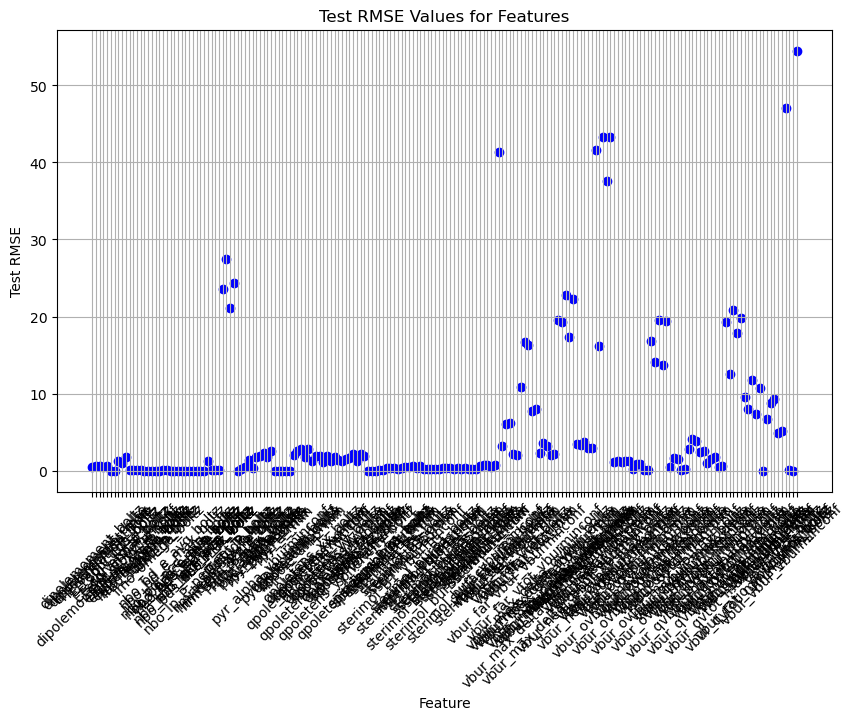

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
data = pd.read_csv('model_evaluation_metrics.csv')

# Scatter plot for RMSE
plt.figure(figsize=(10, 6))
plt.scatter(data['Feature'], data['Test MAE'], color='blue')
plt.title('Test RMSE Values for Features')
plt.xlabel('Feature')
plt.ylabel('Test RMSE')
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [28]:
data.head()

,Feature,Test MAE,R2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,dipolemoment_boltz,0.500087,0.667965,NaN,Average,0.614423
1,dipolemoment_delta,0.585082,0.474037,NaN,Max,0.908874
2,dipolemoment_max,0.556859,0.683286,NaN,NaN,NaN
3,dipolemoment_min,0.440611,0.614003,NaN,NaN,NaN
4,dipolemoment_vburminconf,0.601389,0.582726,NaN,NaN,NaN


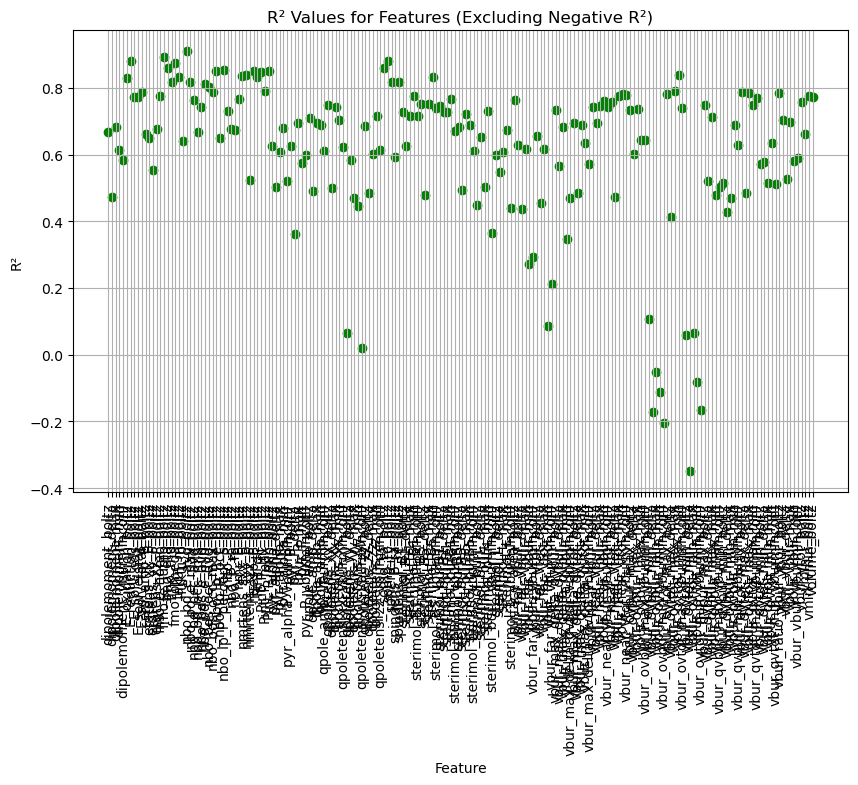

In [29]:
# Filter out rows with negative R²
filtered_data_r2 = data[data['R2'] >= -100]
# Scatter plot for R²
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data_r2['Feature'], filtered_data_r2['R2'], color='green')
plt.title('R² Values for Features (Excluding Negative R²)')
plt.xlabel('Feature')
plt.ylabel('R²')
plt.xticks(rotation=90)
plt.grid()
plt.show()


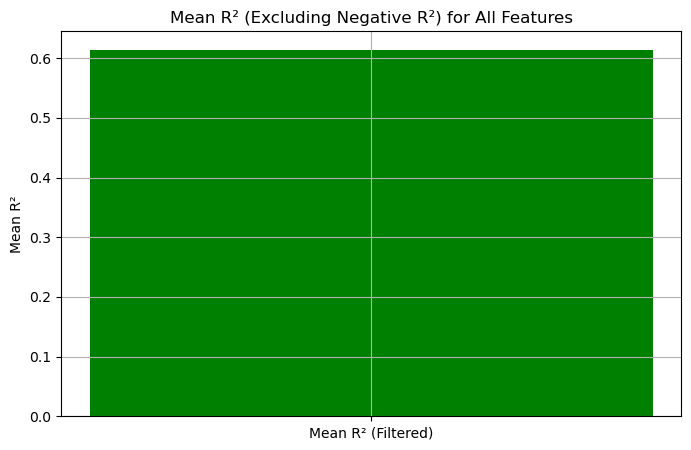

0.6144227760736842


In [30]:
mean_r2_filtered = filtered_data_r2['R2'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean R² (Filtered)'], [mean_r2_filtered], color='green')
plt.title('Mean R² (Excluding Negative R²) for All Features')
plt.ylabel('Mean R²')
plt.grid()
plt.show()
print(mean_r2_filtered)